In [109]:
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split

In [80]:
student_mat = pd.read_csv("../datasets/student-mat.csv", sep = ";")

In [81]:
student_por = pd.read_csv("../datasets/student-por.csv", sep = ";")

In [82]:
studentsdf = pd.concat([student_mat, student_por], ignore_index = True)

In [83]:
studentsdf.select_dtypes("object").columns

Index(['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob',
       'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities',
       'nursery', 'higher', 'internet', 'romantic'],
      dtype='object')

In [84]:
X = studentsdf
y = studentsdf["G3"]

In [85]:
X.select_dtypes("object").columns

Index(['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob',
       'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities',
       'nursery', 'higher', 'internet', 'romantic'],
      dtype='object')

In [86]:
X["school"].head()

0    GP
1    GP
2    GP
3    GP
4    GP
Name: school, dtype: object

In [89]:
X = pd.get_dummies(X, drop_first = True, dtype = int)
X.tail()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,...,guardian_mother,guardian_other,schoolsup_yes,famsup_yes,paid_yes,activities_yes,nursery_yes,higher_yes,internet_yes,romantic_yes
1039,19,2,3,1,3,1,5,4,2,1,...,1,0,0,0,0,1,0,1,1,0
1040,18,3,1,1,2,0,4,3,4,1,...,1,0,0,1,0,0,1,1,1,0
1041,18,1,1,2,2,0,1,1,1,1,...,1,0,0,0,0,1,1,1,0,0
1042,17,3,1,2,1,0,2,4,5,3,...,1,0,0,0,0,0,0,1,1,0
1043,18,3,2,3,1,0,4,4,1,3,...,1,0,0,0,0,0,0,1,1,0


In [96]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

len(X_train), len(X_test)

(835, 209)

In [103]:
pca = PCA(n_components = 2)
X_reduced = pca.fit_transform(X)

X_reduced[:5]

array([[-0.50873155,  0.73629547],
       [-2.24571047, -1.14688174],
       [-2.38216824,  0.16741876],
       [ 3.34836922, -0.06509809],
       [-0.39671915, -0.94246665]])

In [113]:
studentsdf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1044 entries, 0 to 1043
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      1044 non-null   object
 1   sex         1044 non-null   object
 2   age         1044 non-null   int64 
 3   address     1044 non-null   object
 4   famsize     1044 non-null   object
 5   Pstatus     1044 non-null   object
 6   Medu        1044 non-null   int64 
 7   Fedu        1044 non-null   int64 
 8   Mjob        1044 non-null   object
 9   Fjob        1044 non-null   object
 10  reason      1044 non-null   object
 11  guardian    1044 non-null   object
 12  traveltime  1044 non-null   int64 
 13  studytime   1044 non-null   int64 
 14  failures    1044 non-null   int64 
 15  schoolsup   1044 non-null   object
 16  famsup      1044 non-null   object
 17  paid        1044 non-null   object
 18  activities  1044 non-null   object
 19  nursery     1044 non-null   object
 20  higher  

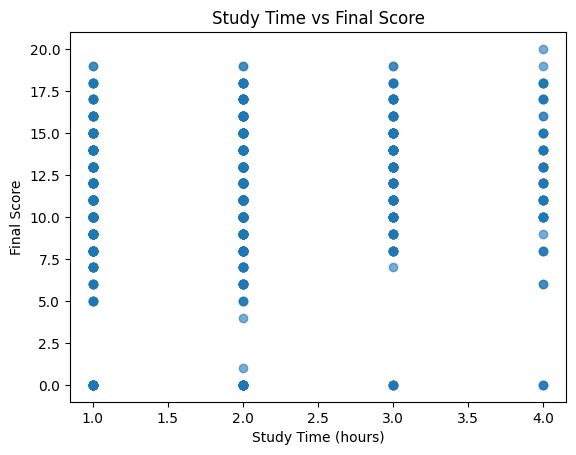

In [115]:
plt.scatter(studentsdf["studytime"], studentsdf["G3"], alpha=0.6)
plt.xlabel("Study Time (hours)")
plt.ylabel("Final Score")
plt.title("Study Time vs Final Score")
plt.show()

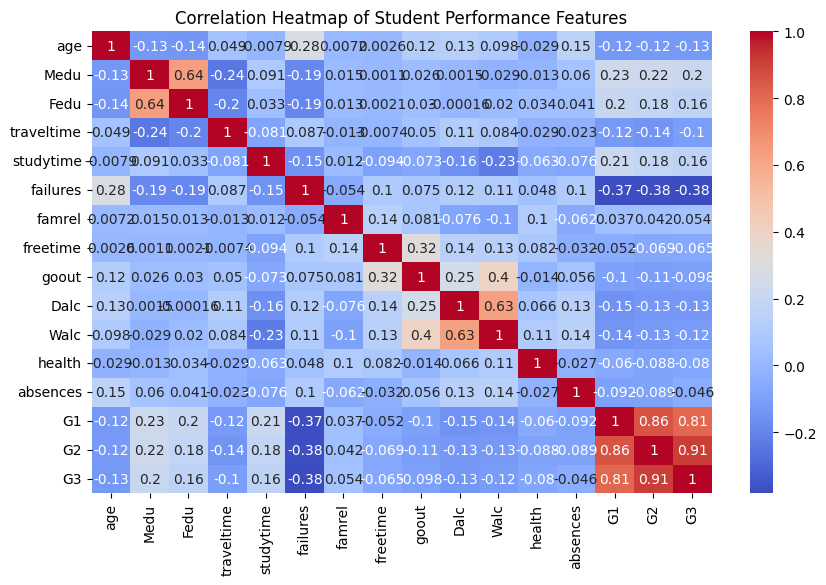

In [118]:
numeric_df = studentsdf.select_dtypes(include=["number"])

plt.figure(figsize=(10, 6))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap of Student Performance Features")
plt.show()


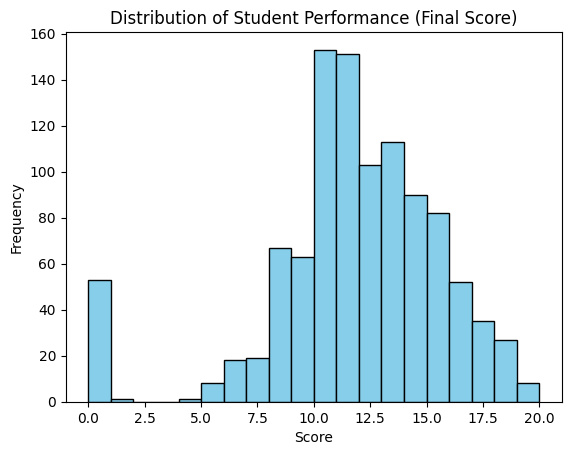

In [119]:
plt.hist(studentsdf["G3"], bins=20, color="skyblue", edgecolor="black")
plt.title("Distribution of Student Performance (Final Score)")
plt.xlabel("Score")
plt.ylabel("Frequency")
plt.show()